# Comparative Analysis of Similarity Metrics for Music Preference Matching

## Project Overview

This project explores how different similarity and distance metrics influence user matching in a music recommendation scenario.

Using the same synthetic music preference dataset, the analysis compares multiple approaches including:

- Manhattan Distance
- Euclidean Distance
- Cosine Similarity

The primary objective of this notebook is to investigate how different mathematical representations of similarity can produce different recommendation behaviors and ranking outcomes.

Throughout the analysis, several important concepts in data science and recommendation systems are explored, including:

- Similarity Analysis
- Distance Metrics
- Feature Engineering
- Scaling and Normalization
- Weighted Features
- Recommendation System Foundations

By keeping the dataset and preprocessing pipeline consistent, the project focuses specifically on understanding how each metric interprets user preferences differently.

This notebook is intended as an educational exploration of similarity-based recommendation systems and the modeling assumptions behind different similarity metrics.

### "One of the key questions explored in this project is whether different similarity metrics produce different recommendation trends even when applied to the same dataset and preprocessing strategy.""

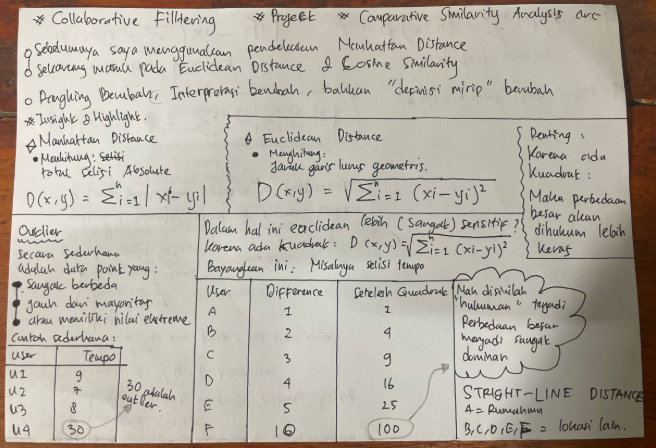
#### Sebelum melangkah lebih jauh, meyakinkan diri sendiri adalah langkah pertama!!!
    “Does Euclidean Distance produce different recommendation trends by penalizing large feature differences more strongly than Manhattan Distance?”
Kemungkinan
- Rangking berubah
- Intepretasi berubah
- Bahkan "Definisi Mirip" pun berubah

# Euclidean Distance Implementation

Euclidean Distance measures the straight-line geometric distance between two points in multidimensional feature space.
Unlike Manhattan Distance, Euclidean Distance squares feature differences before summation, making the metric more sensitive to large feature gaps and outliers.

The objective of this section is to investigate whether Euclidean Distance produces different similarity rankings compared to Manhattan Distance when applied to the same music preference dataset.

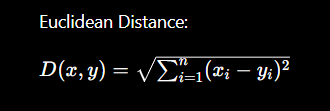

### Load Previous Synthetic Dataset

In [7]:
import pandas as pd

df = pd.read_csv("music_preferences.csv")
# WE USING SIMILAR Synthetic Dataset

In [8]:
print(df.columns)
print(df.info())
print(df.head())

Index(['User', 'Tempo', 'Energy', 'Acousticness', 'Danceability', 'Genre',
       'Mood'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User          50 non-null     object
 1   Tempo         50 non-null     int64 
 2   Energy        50 non-null     int64 
 3   Acousticness  50 non-null     int64 
 4   Danceability  50 non-null     int64 
 5   Genre         50 non-null     object
 6   Mood          50 non-null     object
dtypes: int64(4), object(3)
memory usage: 2.9+ KB
None
  User  Tempo  Energy  Acousticness  Danceability Genre   Mood
0   U1      8       6             3             9  Jazz    Sad
1   U2      7       5             4             8   Pop  Happy
2   U3      3       4             8             2  Jazz    Sad
3   U4      9       8             2             9  Jazz  Happy
4   U5      6       7             5  

### Encoding

In [18]:
#One-Hot Encoding (get_dummies)
df_encoded = pd.get_dummies(df, columns=["Genre","Mood"])
print(df_encoded.head())

  User  Tempo  Energy  Acousticness  Danceability  Genre_Jazz  Genre_Pop  \
0   U1      8       6             3             9        True      False   
1   U2      7       5             4             8       False       True   
2   U3      3       4             8             2        True      False   
3   U4      9       8             2             9        True      False   
4   U5      6       7             5             7       False       True   

   Genre_Rock  Mood_Chill  Mood_Happy  Mood_Sad  
0       False       False       False      True  
1       False       False        True     False  
2       False       False       False      True  
3       False       False        True     False  
4       False       False       False      True  


In [19]:
features = df_encoded.drop(columns=["User"])
features.head()

,Tempo,Energy,Acousticness,Danceability,Genre_Jazz,Genre_Pop,Genre_Rock,Mood_Chill,Mood_Happy,Mood_Sad
0,8,6,3,9,True,False,False,False,False,True
1,7,5,4,8,False,True,False,False,True,False
2,3,4,8,2,True,False,False,False,False,True
3,9,8,2,9,True,False,False,False,True,False
4,6,7,5,7,False,True,False,False,False,True


### Scaling

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(features)

In [21]:
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,Tempo,Energy,Acousticness,Danceability,Genre_Jazz,Genre_Pop,Genre_Rock,Mood_Chill,Mood_Happy,Mood_Sad
0,0.857143,0.571429,0.250,0.888889,1.0,0.0,0.0,0.0,0.0,1.0
1,0.714286,0.428571,0.375,0.777778,0.0,1.0,0.0,0.0,1.0,0.0
2,0.142857,0.285714,0.875,0.111111,1.0,0.0,0.0,0.0,0.0,1.0
3,1.000000,0.857143,0.125,0.888889,1.0,0.0,0.0,0.0,1.0,0.0
4,0.571429,0.714286,0.500,0.666667,0.0,1.0,0.0,0.0,0.0,1.0


# Kenapa Ini Penting? 
Karena nanti:
- feature names tetap terlihat,
- lebih mudah debugging,
- lebih mudah interpretasi,
- lebih nyaman compare analysis.

- Next:
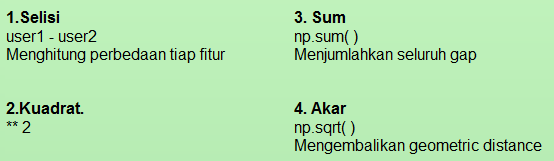

### Euclidean Distance

In [25]:
import numpy as np

def euclidean_distance(user1, user2):
    return np.sqrt(np.sum((user1 -user2) ** 2))

### Similarity Calculation
- Sedikit Intuisi 😄
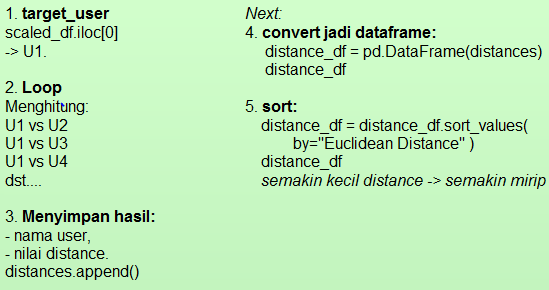

In [26]:
distances = []

target_user = scaled_df.iloc[0]

for i in range(1, len(scaled_df)):
    
    distance = euclidean_distance(
        target_user, 
        scaled_df.iloc[i]
    )
    
    distances.append({
        "User": df.iloc[i]["User"],
        "Euclidean Distance": distance
    })
    

In [41]:
distance_df = pd.DataFrame(distances)

distance_df = distance_df.sort_values(by="Euclidean Distance")
distance_df.head(10)

,User,Euclidean Distance
9,U11,0.292260
12,U14,0.306559
1,U3,1.259921
30,U32,1.432886
23,U25,1.444097
38,U40,1.444097
34,U36,1.448191
2,U4,1.455220
17,U19,1.466773
8,U10,1.471238


In [49]:
order1 = ["U1","U14","U11","U32","U3","U36"]
df_ordered_Manhattan_Distance = df.set_index("User").loc[order1].reset_index()
df_ordered_Manhattan_Distance

,User,Tempo,Energy,Acousticness,Danceability,Genre,Mood
0,U1,8,6,3,9,Jazz,Sad
1,U14,8,8,3,8,Jazz,Sad
2,U11,7,6,4,7,Jazz,Sad
3,U32,7,7,3,8,Jazz,Happy
4,U3,3,4,8,2,Jazz,Sad
5,U36,8,8,2,9,Rock,Sad


In [50]:
order2 = ["U1","U11","U14","U3","U32","U25"]
df_ordered_Euclidean_Distance = df.set_index("User").loc[order2].reset_index()
df_ordered_Euclidean_Distance

,User,Tempo,Energy,Acousticness,Danceability,Genre,Mood
0,U1,8,6,3,9,Jazz,Sad
1,U11,7,6,4,7,Jazz,Sad
2,U14,8,8,3,8,Jazz,Sad
3,U3,3,4,8,2,Jazz,Sad
4,U32,7,7,3,8,Jazz,Happy
5,U25,7,6,4,7,Pop,Sad


After applying Min-Max Scaling and evaluating user similarity using Euclidean Distance, the top similarity ranking produced the following users: U11, U14, U3, U32, and U25.

One particularly interesting observation appears in the third-ranked user (U3). Despite showing relatively large numerical differences compared to the pivot user (U1), U3 still achieved a high similarity ranking.

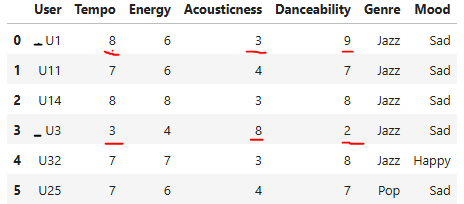

Several feature gaps can be observed between U1 and U3:
- Tempo: 8 vs 3
- Acousticness: 3 vs 8
- Danceability: 9 vs 2

However, both users share the same categorical preferences:
- Genre: Jazz
- Mood: Sad

This suggests that categorical similarity may still contribute meaningfully to the overall similarity calculation even when numerical feature differences are relatively large.

## Manhattan Distance vs Euclidean Distance

Several ranking shifts can be observed when comparing Manhattan Distance and Euclidean Distance.

In Manhattan Distance, the first and second positions were occupied by U14 and U11, while Euclidean Distance reversed the order into U11 and U14.

Additional ranking changes also occurred between U32 and U3, where Manhattan Distance ranked U32 above U3, while Euclidean Distance placed U3 higher than U32.

Finally, the fifth position changed from U36 (Manhattan Distance) to U25 (Euclidean Distance).

These ranking differences indicate that different distance metrics interpret feature differences differently, resulting in distinct recommendation behaviors even when applied to the same dataset and preprocessing strategy.

### Vizualisation

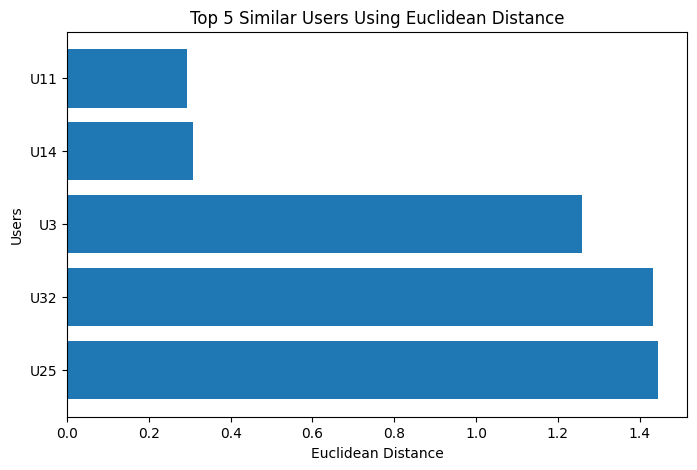

In [53]:
import matplotlib.pyplot as plt

top5 = distance_df.head(5)

plt.figure(figsize=(8,5))

plt.barh(
    top5["User"],
    top5["Euclidean Distance"]
)

plt.xlabel("Euclidean Distance")
plt.ylabel("Users")
plt.title("Top 5 Similar Users Using Euclidean Distance")

plt.gca().invert_yaxis()

plt.savefig(
    "euclidean_distance_top5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()